### SVMs y optimización de hiperparámetros

En este notebook trabajaremos con un dataset simulado de eventos del experimento ATLAS. Cada fila representa un evento de colisión protón–protón, y cada columna corresponde a una variable reconstruida a partir de los objetos físicos detectados en el evento: jets, leptones, energía faltante, etc.

El objetivo es distinguir entre dos tipos de eventos:

- **`ttbar`**: producción de un par top–antitop. Es un proceso mucho más frecuente.
- **`4top`**: producción de cuatro quarks top. Es un proceso mucho más raro y corresponde a nuestra clase positiva.


Basado en Machine learning for physics and Astronomy, Viviana Acquaviva (2023)





In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc
from sklearn.svm import SVC, LinearSVC # Nuevo algoritmo!
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict, cross_validate
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn import metrics
from sklearn.model_selection import GridSearchCV # Nuevo! Para explorar los hiperparámetros del modelo

In [2]:
pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_colwidth', 100)
rc('text', usetex=False)

Leemos las características y las etiquetas  

In [3]:
features = pd.read_csv('ParticleID_features.csv', index_col='ID')

In [4]:
features.head(10)

,MET,METphi,Type_1,P1,P2,P3,P4,Type_2,P5,P6,P7,P8,Type_3,P9,P10,P11,P12,Type_4,P13,P14,P15,P16,Type_5,P17,P18,P19,P20,Type_6,P21,P22,P23,P24,Type_7,P25,P26,P27,P28,Type_8,P29,P30,P31,P32,Type_9,P33,P34,P35,P36,Type_10,P37,P38,P39,P40,Type_11,P41,P42,P43,P44,Type_12,P45,P46,P47,P48,Type_13,P49,P50,P51,P52
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,62803.50,-1.810010,j,137571.0,128444.0,-0.345744,-0.307112,j,174209.0,127932.0,0.826569,2.332000,b,86788.9,84554.9,-0.180795,2.187970,j,140289.0,76955.8,-1.199330,-1.302800,m+,85230.6,70102.4,-0.645689,-1.659540,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,57594.20,-0.509253,j,161529.0,80458.3,-1.318010,1.402050,j,291490.0,68462.9,-2.126740,-2.582310,e-,44270.1,35139.6,-0.706120,-0.371392,e+,72883.9,26902.2,-1.653860,-3.129630,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,82313.30,1.686840,b,167130.0,113078.0,0.937258,-2.068680,j,102423.0,54922.3,1.226850,0.646589,j,60768.9,36244.3,1.102890,-1.434480,j,77714.0,27801.5,1.684610,1.389690,j,26840.0,24469.3,-0.388937,-1.647260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,30610.80,2.617120,j,112267.0,61383.9,-1.211050,-1.457800,b,40647.8,39472.0,-0.024646,-2.222800,j,201589.0,32978.6,-2.496040,1.137810,j,90096.7,26964.5,1.871320,0.817631,j,28235.4,25887.9,-0.411528,2.024290,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,45153.10,-2.241350,j,178174.0,100164.0,1.166880,-0.018721,j,92351.3,69762.1,0.774114,2.568740,j,61625.2,50086.7,0.652572,-3.012800,j,104193.0,31151.0,1.876410,0.865381,j,746585.0,26219.3,4.041820,-0.874169,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,43803.10,0.572184,b,146274.0,111016.0,-0.776311,1.083980,j,1036150.0,109475.0,-2.937790,-1.518380,j,259026.0,71613.8,-1.955480,-1.726540,j,137198.0,59925.9,-1.469500,2.189410,j,95419.6,55847.5,1.123310,0.846395,j,451389.0,53178.9,-2.827840,-2.47964,j,51436.4,50713.2,0.056029,2.258540,j,152293.0,48842.5,-1.80056,-0.704609,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,28100.40,-0.593429,j,458244.0,391557.0,-0.546723,0.013275,b,425427.0,328566.0,-0.728581,-2.411570,j,126694.0,116820.0,-0.350992,2.208790,j,112382.0,111318.0,0.073453,3.030960,j,3039490.0,65143.9,4.535880,1.516880,j,86235.2,65037.1,0.780704,1.50869,b,62675.6,61535.7,0.099510,0.466516,j,82070.6,45537.5,-1.18149,-3.047850,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,166458.00,0.473635,j,848058.0,273398.0,-1.794510,2.763560,j,267149.0,242308.0,-0.425923,-1.534860,b,461064.0,159944.0,-1.719880,1.094360,j,75909.0,73858.8,-0.235076,-0.330519,b,201351.0,53338.2,-2.002180,-2.376840,b,38794.0,37225.5,0.187429,-2.78635,b,40323.4,36915.1,0.411490,1.844490,j,195049.0,28645.2,-2.60528,-1.434260,j,210687.0,26560.5,2.75992,0.315873,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,4664.13,-1.828120,j,477219.0,331550.0,-0.899484,0.698675,b,696365.0,246682.0,-1.697140,-2.285070,j,987005.0,62516.5,-3.451230,-2.207720,j,51561.9,36406.3,-0.881624,-2.923760,j,85262.1,35203.6,-1.527390,2.071480,j,202166.0,26361.8,-2.725680,-2.21350,j,56071.6,25934.6,-1.403180,1.130990,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Cada fila del dataset corresponde a un evento de colisión protón-protón.
Para cada evento se conoce:
- Energía faltante:
  - `MET`: energía transversa faltante (*missing transverse energy*)
  - `METphi`: ángulo azimutal asociado a la dirección de la energía faltante
- Información de cada partícula reconstruida: Para cada partícula se registra:
    - Tipo de partícula, que puede ser: electrón, positrón, fotón, jet, b-jet, muón con carga positiva, muón con carga negativa
    - 4-vector, que describe la cinemática de la partícula. En este dataset, el 4-vector incluye: energía, momento transversal, pseudorapidez $\eta$ y ángulo azimutal $\phi$


In [5]:
features.shape

(5000, 67)

In [6]:
y = np.genfromtxt('ParticleID_labels.txt', dtype = str)

In [7]:
y

array(['ttbar', 'ttbar', 'ttbar', ..., 'ttbar', '4top', 'ttbar'],
      shape=(5000,), dtype='<U5')

### Objetivo del problema

Queremos entrenar un clasificador que distinga entre dos tipos de eventos:

- `ttbar`: producción de un par top-antitop.
- `4top`: producción de cuatro quarks top.

#### Necesitamos transformar las dos categorías de targets desde un string a un valor numérico, como 0/1. Podemos usar la función [`LabelEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html) de sklearn

In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder() #cambia las categorías a 1...N

In [9]:
y

array(['ttbar', 'ttbar', 'ttbar', ..., 'ttbar', '4top', 'ttbar'],
      shape=(5000,), dtype='<U5')

In [10]:
y = le.fit_transform(y)

In [11]:
le.classes_

array(['4top', 'ttbar'], dtype='<U5')

`LabelEncoder` asigna números a las clases en el orden definido por `le.classes_`.  
Como queremos que `4top` sea la clase positiva, revisamos la codificación y, si es necesario, invertimos las etiquetas.

In [12]:
target = np.abs(y - 1)

In [13]:
target # Ahora sí

array([0, 0, 0, ..., 0, 1, 0], shape=(5000,))

In [14]:
y.shape

(5000,)

#### Echemos un vistazo a las características

In [15]:
features.describe() #Esto excluye a las columnas con datos no-numéricos

,MET,METphi,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16,P17,P18,P19,P20,P21,P22,P23,P24,P25,P26,P27,P28,P29,P30,P31,P32,P33,P34,P35,P36,P37,P38,P39,P40,P41,P42,P43,P44,P45,P46,P47,P48,P49,P50,P51,P52
count,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,4.997000e+03,4.997000e+03,4997.000000,4997.000000,4.950000e+03,4950.000000,4950.000000,4950.000000,4.717000e+03,4717.000000,4717.000000,4717.000000,4.002000e+03,4002.000000,4002.000000,4002.000000,2.871000e+03,2871.00000,2871.000000,2871.000000,1.889000e+03,1889.000000,1889.000000,1889.000000,1.186000e+03,1186.000000,1186.000000,1186.000000,7.290000e+02,729.000000,729.000000,729.000000,4.420000e+02,442.000000,442.000000,442.000000,2.610000e+02,261.000000,261.000000,261.000000,1.270000e+02,127.000000,127.000000,127.000000,5.600000e+01,56.000000,56.000000,56.000000
mean,64071.074332,-0.028916,3.301357e+05,1.540486e+05,-0.039812,-0.003049,2.527799e+05,1.080302e+05,-0.029936,0.007327,2.117980e+05,74863.343131,-0.025104,0.011845,1.805997e+05,57289.049481,0.010723,0.045266,1.780366e+05,48798.018516,0.015167,-0.031312,1.705620e+05,44042.67015,-0.022948,0.014522,1.628825e+05,41151.069666,0.002228,0.006738,1.581409e+05,40250.387015,0.072349,-0.035907,1.596814e+05,40139.289849,0.061654,-0.045868,1.574039e+05,39703.038235,0.118543,0.024249,1.561160e+05,38173.716092,0.029455,0.026422,1.631051e+05,34876.849606,0.206978,-0.001085,1.456600e+05,36151.183929,-0.000879,0.219260
std,60525.122480,1.819257,3.068202e+05,1.149469e+05,1.361762,1.814855,2.638580e+05,8.136261e+04,1.439105,1.828832,2.510361e+05,46309.512365,1.577316,1.802715,2.383403e+05,32013.857623,1.634072,1.812078,2.577958e+05,26252.978520,1.744489,1.784248,2.381745e+05,23510.65367,1.806611,1.811101,2.269341e+05,20988.953157,1.815312,1.771888,2.118782e+05,26556.025657,1.836492,1.796932,2.308620e+05,30074.756789,1.842798,1.788596,2.165489e+05,30502.312276,1.872084,1.826435,2.319016e+05,29324.658352,1.884750,1.753017,2.248603e+05,20433.767238,1.998859,1.949004,1.943657e+05,25861.883410,1.941707,1.910400
min,290.756000,-3.141010,3.857940e+04,2.825400e+04,-4.110220,-3.140710,1.087540e+04,1.080000e+04,-4.668790,-3.140530,1.221050e+04,10639.800000,-4.520250,-3.141480,1.169190e+04,10818.000000,-4.616550,-3.136130,1.110310e+04,10287.000000,-4.778980,-3.139040,1.070330e+04,10066.90000,-4.930230,-3.140380,1.197700e+04,11260.200000,-4.758150,-3.135630,1.380860e+04,10973.300000,-4.606330,-3.132610,1.119760e+04,10067.900000,-4.814380,-3.136380,1.615530e+04,10183.700000,-4.803880,-3.135910,2.004750e+04,14800.200000,-4.400470,-3.130690,1.780380e+04,12987.900000,-4.447660,-3.139820,2.512510e+04,14836.000000,-4.448760,-2.990730
25%,24352.375000,-1.619905,1.369522e+05,8.883690e+04,-1.035570,-1.574213,1.007510e+05,6.321840e+04,-1.060500,-1.602460,7.636905e+04,46549.475000,-1.125620,-1.547418,5.999090e+04,36097.700000,-1.121240,-1.518030,5.278370e+04,30891.650000,-1.198468,-1.550615,5.007050e+04,28453.95000,-1.250050,-1.586675,4.695560e+04,27963.500000,-1.231420,-1.475380,4.535515e+04,27140.550000,-1.243962,-1.626688,4.387110e+04,26825.000000,-1.226980,-1.513330,4.410735e+04,26589.250000,-1.223240,-1.422415,4.092160e+04,25298.300000,-1.413650,-1.270700,4.365005e+04,24742.500000,-1.259230,-1.817600,4.112588e+04,24974.125000,-1.243362,-1.490900
50%,46814.400000,-0.055612,2.263525e+05,1.182015e+05,-0.038731,-0.009037,1.659740e+05,8.584360e+04,-0.057428,0.015111,1.288565e+05,62498.400000,-0.040648,0.034238,9.922610e+04,48949.200000,-0.035512,0.060279,9.206885e+04,41054.850000,0.054393,-0.079641,8.593460e+04,37378.30000,-0.046667,0.040528,7.975460e+04,34681.700000,0.025305,0.046141,8.315485e+04,33683.550000,0.156083,-0.015617,7.894980e+04,33328.000000,0.072709,-0.052590,7.609735e+04,30942.700000,0.035675,0.090282,7.568430e+04,29479.700000,-0.088908,-0.041002,8.050910e+04,28262.800000,0.120301,-0.232455,9.553645e+04,27353.550000,-0.121213,0.128103
75%,83032.350000,1.537323,4.077158e+05,1.771265e+05,0.943598,1.542370,2.9999

In [16]:
features.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 67 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   MET      5000 non-null   float64
 1   METphi   5000 non-null   float64
 2   Type_1   5000 non-null   str    
 3   P1       5000 non-null   float64
 4   P2       5000 non-null   float64
 5   P3       5000 non-null   float64
 6   P4       5000 non-null   float64
 7   Type_2   4997 non-null   str    
 8   P5       4997 non-null   float64
 9   P6       4997 non-null   float64
 10  P7       4997 non-null   float64
 11  P8       4997 non-null   float64
 12  Type_3   4950 non-null   str    
 13  P9       4950 non-null   float64
 14  P10      4950 non-null   float64
 15  P11      4950 non-null   float64
 16  P12      4950 non-null   float64
 17  Type_4   4717 non-null   str    
 18  P13      4717 non-null   float64
 19  P14      4717 non-null   float64
 20  P15      4717 non-null   float64
 21  P16      4717 non-null   

### Importante:

En este dataset, los NaN aparecen porque no todos los eventos tienen la misma cantidad de partículas reconstruidas.  
Al reemplazar por 0, estamos codificando implícitamente la ausencia de una partícula.

Esto puede ser razonable, pero también puede introducir una señal artificial: el modelo podría aprender no solo de las variables físicas, sino también de cuántas partículas fueron registradas.


**¿Qué podemos hacer?**

#### Opción 1: Sólo considerar las primeras 16 columnas (4 primeros productos)

De esta forma, reducimos los problemas de manipulación o de imputación de datos faltantes.


Tenemos un trade-off entre tener más features, pero si tenemos más, tendremos muchos datos faltantes que tendremos que reemplazar (imputing), o mantenemos menos features, pero el problema es más simple

In [17]:
#limitamos los features
features_lim = features[['MET', 'METphi', 'P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9', 'P10', 'P11',
       'P12',  'P13', 'P14', 'P15', 'P16']]

In [18]:
features_lim.head()

,MET,METphi,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16
ID,,,,,,,,,,,,,,,,,,
0,62803.5,-1.810010,137571.0,128444.0,-0.345744,-0.307112,174209.0,127932.0,0.826569,2.332000,86788.9,84554.9,-0.180795,2.187970,140289.0,76955.8,-1.19933,-1.302800
1,57594.2,-0.509253,161529.0,80458.3,-1.318010,1.402050,291490.0,68462.9,-2.126740,-2.582310,44270.1,35139.6,-0.706120,-0.371392,72883.9,26902.2,-1.65386,-3.129630
2,82313.3,1.686840,167130.0,113078.0,0.937258,-2.068680,102423.0,54922.3,1.226850,0.646589,60768.9,36244.3,1.102890,-1.434480,77714.0,27801.5,1.68461,1.389690
3,30610.8,2.617120,112267.0,61383.9,-1.211050,-1.457800,40647.8,39472.0,-0.024646,-2.222800,201589.0,32978.6,-2.496040,1.137810,90096.7,26964.5,1.87132,0.817631
4,45153.1,-2.241350,178174.0,100164.0,1.166880,-0.018721,92351.3,69762.1,0.774114,2.568740,61625.2,50086.7,0.652572,-3.012800,104193.0,31151.0,1.87641,0.865381


In [19]:
features_lim.describe()

,MET,METphi,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16
count,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,4.997000e+03,4.997000e+03,4997.000000,4997.000000,4.950000e+03,4950.000000,4950.000000,4950.000000,4.717000e+03,4717.000000,4717.000000,4717.000000
mean,64071.074332,-0.028916,3.301357e+05,1.540486e+05,-0.039812,-0.003049,2.527799e+05,1.080302e+05,-0.029936,0.007327,2.117980e+05,74863.343131,-0.025104,0.011845,1.805997e+05,57289.049481,0.010723,0.045266
std,60525.122480,1.819257,3.068202e+05,1.149469e+05,1.361762,1.814855,2.638580e+05,8.136261e+04,1.439105,1.828832,2.510361e+05,46309.512365,1.577316,1.802715,2.383403e+05,32013.857623,1.634072,1.812078
min,290.756000,-3.141010,3.857940e+04,2.825400e+04,-4.110220,-3.140710,1.087540e+04,1.080000e+04,-4.668790,-3.140530,1.221050e+04,10639.800000,-4.520250,-3.141480,1.169190e+04,10818.000000,-4.616550,-3.136130
25%,24352.375000,-1.619905,1.369522e+05,8.883690e+04,-1.035570,-1.574213,1.007510e+05,6.321840e+04,-1.060500,-1.602460,7.636905e+04,46549.475000,-1.125620,-1.547418,5.999090e+04,36097.700000,-1.121240,-1.518030
50%,46814.400000,-0.055612,2.263525e+05,1.182015e+05,-0.038731,-0.009037,1.659740e+05,8.584360e+04,-0.057428,0.015111,1.288565e+05,62498.400000,-0.040648,0.034238,9.922610e+04,48949.200000,-0.035512,0.060279
75%,83032.350000,1.537323,4.077158e+05,1.771265e+05,0.943598,1.542370,2.999950e+05,1.238700e+05,1.028340,1.605210,2.421225e+05,89587.500000,1.066302,1.570887,1.914340e+05,68782.100000,1.159480,1.612220
max,692674.000000,3.141130,3.186360e+06,1.276710e+06,4.141410,3.138540,3.587700e+06,1.146330e+06,4.559150,3.139200,2.800410e+06,788338.000000,4.798090,3.139020,2.503590e+06,481884.000000,4.730480,3.139660


Todavía tenemos datos faltantes (valores NaN). Los reemplazaremos con 0

In [20]:
features_lim = features_lim.fillna(0) #Llena todo lo que es NaN con 0

#### ¿Qué opina de esta estrategia?



Por un lado esta bien, ya que de esta manera podemos analizar los datos (con datos NaN se complica un poco), y podemos analizar lo que nos interesa, reconocer la interaccción top y anti-top, y la interacción 4 top. Pero, desde un punto de vista más físico, se pierde información, ya que estamos cortando los datos y asumiendo información que en realidad no poseemos, lo cual puede derivar en un mal modelo.

#### Si revisamos nuevamente con `describe`

In [21]:
features_lim.describe()

,MET,METphi,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16
count,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000
mean,64071.074332,-0.028916,3.301357e+05,1.540486e+05,-0.039812,-0.003049,2.526283e+05,1.079653e+05,-0.029918,0.007323,2.096800e+05,74114.709700,-0.024853,0.011727,1.703778e+05,54046.489280,0.010116,0.042704
std,60525.122480,1.819257,3.068202e+05,1.149469e+05,1.361762,1.814855,2.638514e+05,8.138121e+04,1.438673,1.828283,2.506651e+05,46675.655162,1.569410,1.793678,2.352279e+05,33795.723384,1.587146,1.760070
min,290.756000,-3.141010,3.857940e+04,2.825400e+04,-4.110220,-3.140710,0.000000e+00,0.000000e+00,-4.668790,-3.140530,0.000000e+00,0.000000,-4.520250,-3.141480,0.000000e+00,0.000000,-4.616550,-3.136130
25%,24352.375000,-1.619905,1.369522e+05,8.883690e+04,-1.035570,-1.574213,1.007050e+05,6.320943e+04,-1.059270,-1.599617,7.488228e+04,46165.375000,-1.108390,-1.532478,5.480870e+04,33959.400000,-1.050477,-1.424080
50%,46814.400000,-0.055612,2.263525e+05,1.182015e+05,-0.038731,-0.009037,1.658985e+05,8.581595e+04,-0.056810,0.012737,1.277135e+05,62167.100000,-0.023321,0.006687,9.259335e+04,47278.800000,0.000000,0.000000
75%,83032.350000,1.537323,4.077158e+05,1.771265e+05,0.943598,1.542370,2.999058e+05,1.238520e+05,1.028055,1.601880,2.406498e+05,89065.300000,1.048617,1.553310,1.831228e+05,66846.300000,1.085627,1.521765
max,692674.000000,3.141130,3.186360e+06,1.276710e+06,4.141410,3.138540,3.587700e+06,1.146330e+06,4.559150,3.139200,2.800410e+06,788338.000000,4.798090,3.139020,2.503590e+06,481884.000000,4.730480,3.139660


Ahora tenemos tamaños consistentes para poder usarlos como features, PERO hay que estar conciente de los efectos negativos que puede traer nuestra estrategia de imputación

## Benchmark inicial

En este notebook, el benchmark principal es el desempeño de estrategias simples antes de usar un SVM más flexible. Primero comparamos contra un clasificador que siempre predice la clase mayoritaria, ya que el dataset está desbalanceado. Luego, un clasificador aleatorio, es decir, asigna un valor aleatorio a cada clase. Y también usamos un `LinearSVC` con escalamiento como benchmark lineal: una referencia razonable para saber si necesitamos modelos más complejos, como SVM con kernels no lineales.

In [22]:
np.sum(target)/len(target) #distribución

np.float64(0.1622)

84\% en la etiqueta negativa, 16\% en la etiqueta positiva.

Esto significa que un clasificador que pone todo en la clase negativa (lazy classifier) tendrá un 84% de accuracy

Cómo lo haría un clasificador aleatorio que asigna un valor aleatorio a la distribución de clase?

In [23]:
#Numerical solution

acc=0
for i in range(1000): #1000 iteraciones del proceso
    x = np.random.choice(target,5000) #generamos 5000 etiquetas aleatorias
    acc += metrics.accuracy_score(target,x) #calculamos accuracy promedio en las 1000 iteraciones
print(acc/1000)

#Analytic solution
#P(Clase 1)^2 + P(Clase 2)^2 exactitud esperada


print(0.8378*(0.8378) + 0.1622*0.1622)

0.7283932000000001
0.72821768


En conclusión, un clasificador aleatorio tendrá 73% accuracy, un lazy classfier tiene 83% accuracy. Este análisis es útil para tener una expectativa de qué es un "buen resultado" y qué significa una mejora significativa


### Ahora empezaremos con un modelo lineal  model = SVC()

Definimos una estrategia CV, establecemos un benchmark para un modelo lineal no regularization (parámetro C muy alto)

**Antes de correr el modelo, discuta:**

1. ¿Esperamos que un modelo lineal separe bien eventos `ttbar` y `4top`?
2. ¿Qué significaría que el modelo lineal tenga una accuracy cercana al clasificador mayoritario?
3. ¿Qué métrica sería más relevante si queremos detectar eventos `4top`: accuracy, precision, recall o F1-score?

**RESPUESTAS:**
1. Lo más esperable es que no, ya que los datos seguramente ienen correlaciones complejas y no lineales, donde no haya una separación clara entre clases. 

2. Significaría que el modelo no aprendió a discriminar nada y simplemente se dedicó a predecir la clase mayoritaria para casi todos los datos. El modelo no sabe identificar y debido al desbalance se inclina a predecir la clase con mayor cantidad de datos.

3. F1-score (o Recall). La accuracy es una métrica engañosa ante el desbalance de datos. El Recall evalúa qué tan bien capturamos la señal rara de 4top, mientras que el F1-score da el balance óptimo entre no perder eventos de 4top y no contaminar la muestra con ttbar.

In [24]:
bmodel = LinearSVC(dual = False, C=1000)
# Para modelo lineal, se prefiere dual=False cuando  n_samples > n_features.
#( el primal trabaja con las features, el dual trabaja con los alpha_i que estan asociados al numero de muestras)
# Si no, no va a converger!


**Qué signifca la elección de C grande?**

In [25]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=101)

In [26]:
l_benchmark_lim = cross_validate(bmodel, features_lim, target, cv = cv, scoring = 'accuracy', return_train_score=True)


In [27]:
l_benchmark_lim

{'fit_time': array([0.0686419 , 0.02736735, 0.02542734, 0.02593803, 0.02859831]),
 'score_time': array([0.0047524 , 0.00373602, 0.00413465, 0.0041182 , 0.00349689]),
 'test_score': array([0.841, 0.825, 0.829, 0.83 , 0.833]),
 'train_score': array([0.8315 , 0.83275, 0.8315 , 0.83125, 0.832  ])}

In [28]:
np.round(l_benchmark_lim['test_score'].mean(),3), np.round(l_benchmark_lim['test_score'].std(), 3)

(np.float64(0.832), np.float64(0.005))

El promedio de accuracy para este caso parece alto, pero es igual de alto que el lazy classifier.
Podemos chequear las etiquetas con `cross_val_predict`, que compila las etiquetas predichas cuando cada objeto estaba en el fold test

In [29]:
ypred_bench_lim = cross_val_predict(bmodel, features_lim, target, cv = cv)

In [30]:
ypred_bench_lim

array([0, 0, 0, ..., 0, 0, 0], shape=(5000,))

### Pregunta: Qué podríamos haber hecho antes de haber construído el modelo SVM?

<details>
<summary>Mostrar explicación</summary>

### Escalar!

Los SVM son sensibles a la escala de las variables porque trabajan en el espacio de características.
La optimización  depende de productos punto entre pares de ejemplos:

$$
\mathbf{x}_i \cdot \mathbf{x}_j
$$

Por eso escalamos las features antes de entrenar un SVM. Una opción común es usar `StandardScaler`, que transforma cada feature para que tenga media 0 y desviación estándar 1.



</details>


In [31]:
from sklearn.pipeline import make_pipeline #Podemos construir varios pasos al mismo tiempo

¿Por qué usamos Pipeline?

Porque en validación cruzada, el escalamiento debe aprenderse usando solo los datos de entrenamiento de cada fold.  
Si escalamos todo el dataset antes de hacer CV, estaríamos usando información del conjunto de prueba para transformar los datos.  
Eso sería una forma sutil de data leakage.

[`make_pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.make_pipeline.html)  permite encadenar varios pasos de preprocesamiento y modelado en un solo objeto.


In [32]:
piped_model = make_pipeline(StandardScaler(), LinearSVC(dual = False, C = 1000))
#modelo benchmark (de referencia)
benchmark_lim_piped = cross_validate(piped_model, features_lim, target, cv = cv, scoring = 'accuracy', return_train_score=True)

In [33]:
benchmark_lim_piped

{'fit_time': array([0.03148651, 0.02977037, 0.02621889, 0.02417445, 0.0366106 ]),
 'score_time': array([0.00650024, 0.00833535, 0.00728106, 0.00560141, 0.00870275]),
 'test_score': array([0.894, 0.889, 0.89 , 0.892, 0.899]),
 'train_score': array([0.89575, 0.895  , 0.895  , 0.89825, 0.89275])}

In [34]:
np.round(benchmark_lim_piped['test_score'].mean(),3), np.round(benchmark_lim_piped['test_score'].std(), 3)

(np.float64(0.893), np.float64(0.004))

In [35]:
np.round(benchmark_lim_piped['train_score'].mean(),3), np.round(benchmark_lim_piped['train_score'].std(), 3)

(np.float64(0.895), np.float64(0.002))

Esto es una mejora!


Ahora necesitamos **diagnosticar** nuestro modelo:

Si comparamos el score para prueba y entrenamiento, notamos que hay un problema....
Miremos la curva de aprendizaje, que nos ayudará a mirar esto mejor y nos indicará si necesitamos más datos

### Curva de aprendizaje

In [36]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=5,
                        n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 5), scoring = 'accuracy', scale = False):
    """
    Generate a simple plot of the test and training learning curve.

    Parameters
    ----------
    estimator : object type that implements the "fit" and "predict" methods
        An object of that type which is cloned for each validation.

    title : string
        Title for the chart.

    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.

    y : array-like, shape (n_samples) or (n_samples, n_features), optional
        Target relative to X for classification or regression;
        None for unsupervised learning.

    ylim : tuple, shape (ymin, ymax), optional
        Defines minimum and maximum yvalues plotted.

    cv : int, cross-validation generator or an iterable, optional
        Determines the cross-validation splitting strategy.
        Possible inputs for cv are:
          - None, to use the default 3-fold cross-validation,
          - integer, to specify the number of folds.
          - :term:`CV splitter`,
          - An iterable yielding (train, test) splits as arrays of indices.

        For integer/None inputs, if ``y`` is binary or multiclass,
        :class:`StratifiedKFold` used. If the estimator is not a classifier
        or if ``y`` is neither binary nor multiclass, :class:`KFold` is used.

        Refer :ref:`User Guide <cross_validation>` for the various
        cross-validators that can be used here.

    n_jobs : int or None, optional (default=None)
        Number of jobs to run in parallel.
        ``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.
        ``-1`` means using all processors. See :term:`Glossary <n_jobs>`
        for more details.

    train_sizes : array-like, shape (n_ticks,), dtype float or int
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve. If the dtype is float, it is regarded as a
        fraction of the maximum size of the training set (that is determined
        by the selected validation method), i.e. it has to be within (0, 1].
        Otherwise it is interpreted as absolute sizes of the training sets.
        Note that for classification the number of samples usually have to
        be big enough to contain at least one sample from each class.
        (default: np.linspace(0.1, 1.0, 5))
    """
    plt.figure()
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("# of training examples",fontsize = 14)

    plt.ylabel("Accuracy score",fontsize = 14)

    if (scale == True):
        scaler = sklearn.preprocessing.StandardScaler()
        X = scaler.fit_transform(X)

    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring = scoring)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
#    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="b")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="b",
             label="Training score from CV")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Test score from CV")

    plt.legend(loc="best",fontsize = 12)
    return plt

In [37]:
cv

StratifiedKFold(n_splits=5, random_state=101, shuffle=True)

<module 'matplotlib.pyplot' from '/home/fabian/Documentos/Universidad/Computacional_I/.venv/lib/python3.12/site-packages/matplotlib/pyplot.py'>

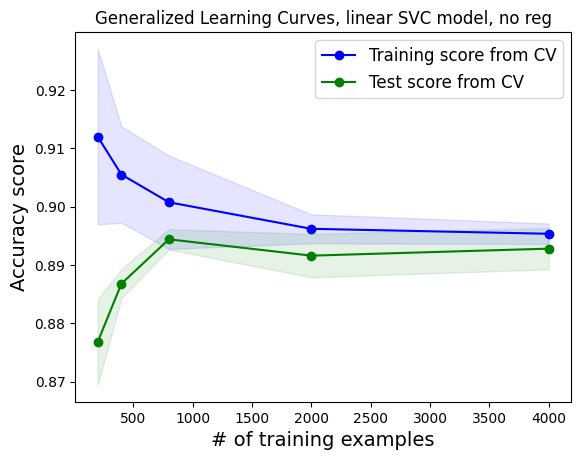

In [38]:
plot_learning_curve(piped_model, 'Generalized Learning Curves, linear SVC model, no reg',
                    features_lim, target, train_sizes = np.array([0.05,0.1,0.2,0.5,1.0]), cv = cv)

In [39]:
# Obtener predicciones usando validación cruzada
ypred_linear = cross_val_predict(
    piped_model,
    features_lim,
    target,
    cv=cv
)

#### Genere una matriz de confusión para esre modelo y evalúe el desempeño del modelo a partir del resultado.

también puede usar la función [`classification_report`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) de `sklearn`

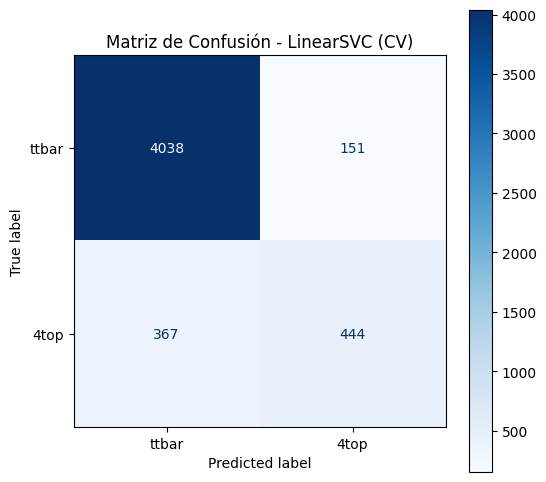

              precision    recall  f1-score   support

       ttbar       0.92      0.96      0.94      4189
        4top       0.75      0.55      0.63       811

    accuracy                           0.90      5000
   macro avg       0.83      0.76      0.79      5000
weighted avg       0.89      0.90      0.89      5000



In [44]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
# Obtener predicciones usando tu validación cruzada (cv)
y_pred = cross_val_predict(piped_model, features_lim, target, cv=cv)

# Generar y graficar la matriz de confusión
cm = confusion_matrix(target, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['ttbar', '4top'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Matriz de Confusión - LinearSVC (CV)')
plt.show()

# Reporte de métricas detallado por clase
print(classification_report(target, y_pred, target_names=['ttbar', '4top']))

## Conclusiones del benchmark lineal

1. En la curva de aprendizaje, ¿los scores de entrenamiento y validación son altos o bajos?  
   ¿Están separados o son parecidos?

2. ¿La curva sugiere alto bias o alta variance?  
   Justifique usando la relación entre score de entrenamiento y validación.

3. Considerando que usamos \(C=1000\), ¿qué nos dice este resultado sobre la capacidad del modelo lineal?

4. En la matriz de confusión, ¿el modelo detecta bien los eventos `4top` o tiende a clasificarlos como `ttbar`?

5. ¿qué métrica muestra mejor el problema con la clase minoritaria: accuracy, precision, recall o F1-score?

6. ¿El modelo lineal supera realmente los benchmarks ingenuos, o su buen desempeño se explica principalmente por el desbalance de clases?

7. ¿Qué evidencia nos indica que necesitamos un modelo más flexible que una frontera lineal?

**RESPUESTAS:**

1. Son relativamente altos en apariencia ($\sim 89\% - 90\%$), pero están muy parecidos y prácticamente pegados (la brecha entre el train y validation es casi cero).

2. Sugiere alto bias (underfitting). Ambos scores convergen juntos muy rápido en un valor ($\sim 89\%$) sin separación entre ellos, lo que indica que no hay sobreajuste (baja varianza), sino falta de capacidad del modelo. 

3. Nos dice que el modelo no puede resolver el problema por limitaciones geométricas. Al no tener casi regularización ($C=1000$) y aun así no lograr ajustar mejor los datos, se confirma que una clasificación lineal es incapaz de separar ambas clases.

4. Tiende a clasificarlos como ttbar. Falla en casi la mitad de las predicciones de la señal, clasificando 367 de los 811 eventos de 4top como si fueran ttbar.

5. El Recall ($0.55$) (y por ende el F1-score de $0.63$). La accuracy es engañosa ($0.90$) porque se infla prediciendo bien la clase mayoritaria. 

6. Se explica principalmente por el desbalance de clases. Como la clase ttbar representa el $83.8\%$ del dataset ($4189 / 5000$), un modelo ingenuo que solo prediga ttbar obtendría esa misma tasa de acierto sin aprender nada de los datos reales.

7. El bajo Recall en 4top ($0.55$) sumado al estancamiento temprano de las curvas de aprendizaje a pesar de tener un $C$ elevado. Esto demuestra que agregar más datos no mejorará el resultado sin un kernel no lineal. 

## Optimización de hiperparámetros

[`GridSearchCV`](https://scikit-learn.org/stable/modules/grid_search.html)selecciona los hiperparámetros que obtienen el mejor desempeño promedio en validación cruzada. Sin embargo, ese score puede ser optimista, porque los mismos folds de validación se usaron para elegir la mejor combinación de hiperparámetros.
Para estimar mejor el desempeño esperado en datos nuevos, se puede usar **validación cruzada anidada**. En este procedimiento, una validación cruzada interna selecciona los hiperparámetros, mientras que una validación cruzada externa evalúa el modelo seleccionado.
La idea central es no usar la misma información para elegir el modelo y para reportar su desempeño final.

La validación cruzada anidada es más rigurosa, pero no siempre vale la pena implementarla. Puede ser muy costosa, porque requiere repetir la búsqueda de hiperparámetros dentro de cada fold externo.En este notebook usaremos `GridSearchCV` para seleccionar hiperparámetros y comparar modelos, pero debemos recordar que el mejor score obtenido puede ser algo optimista. Si el objetivo fuera reportar un resultado final de investigación de manera rigurosa, sería mejor usar un conjunto de prueba independiente o validación cruzada anidada.

In [40]:
#ahora usamos la version general SVC y no la lineal, para cambiar el kernel
piped_model = make_pipeline(StandardScaler(), SVC())

piped_model.get_params() # esto nos muestra los parámetros para el scaler y el clasificador

{'memory': None,
 'steps': [('standardscaler', StandardScaler()), ('svc', SVC())],
 'transform_input': None,
 'verbose': False,
 'standardscaler': StandardScaler(),
 'svc': SVC(),
 'standardscaler__copy': True,
 'standardscaler__with_mean': True,
 'standardscaler__with_std': True,
 'svc__C': 1.0,
 'svc__break_ties': False,
 'svc__cache_size': 200,
 'svc__class_weight': None,
 'svc__coef0': 0.0,
 'svc__decision_function_shape': 'ovr',
 'svc__degree': 3,
 'svc__gamma': 'scale',
 'svc__kernel': 'rbf',
 'svc__max_iter': -1,
 'svc__probability': 'deprecated',
 'svc__random_state': None,
 'svc__shrinking': True,
 'svc__tol': 0.001,
 'svc__verbose': False}

### Podemos definir un diccionario de valores parámetros para correr la optimización

Note que esto tomará tiempo (~3 min en mi computador)

Una vez que corramos esta celda, el objeto modelo tendra atributos de "best_score_", "best_params_" y "best_estimator_", que nos da acceso al estimador óptimo y "cv_results_" que pueden ser utilizados para visualizar la performance de todos los modelo

In [42]:
%%time
#optimizando SVC, TODAVIA NO ES CV ANIDADA!

#Probamos kernel polinomial y gaussiano, parámetros gamma y degree,
# además del parámetro de regularización
parameters = {'svc__kernel':['poly', 'rbf'], \
              'svc__gamma':[0.00001,'scale', 0.01, 0.1], 'svc__C':[0.1, 1.0, 10.0, 100.0, 1000], \
              'svc__degree': [2, 4, 8]}

# CV para todos los valores de los parámetros del GridSearch
model = GridSearchCV(piped_model, parameters, cv = StratifiedKFold(n_splits=5, shuffle=True), \
                     verbose = 2, n_jobs = 4, return_train_score=True)
model.fit(features_lim,target)

print('Best params, best score:', "{:.4f}".format(model.best_score_), \
      model.best_params_)

Fitting 5 folds for each of 120 candidates, totalling 600 fits


[CV] END svc__C=0.1, svc__degree=2, svc__gamma=1e-05, svc__kernel=poly; total time=   0.3s
[CV] END svc__C=0.1, svc__degree=2, svc__gamma=1e-05, svc__kernel=poly; total time=   0.4s
[CV] END svc__C=0.1, svc__degree=2, svc__gamma=1e-05, svc__kernel=poly; total time=   0.4s
[CV] END svc__C=0.1, svc__degree=2, svc__gamma=1e-05, svc__kernel=poly; total time=   0.4s
[CV] END svc__C=0.1, svc__degree=2, svc__gamma=1e-05, svc__kernel=poly; total time=   0.4s
[CV] END svc__C=0.1, svc__degree=2, svc__gamma=1e-05, svc__kernel=rbf; total time=   0.5s
[CV] END svc__C=0.1, svc__degree=2, svc__gamma=1e-05, svc__kernel=rbf; total time=   0.5s
[CV] END svc__C=0.1, svc__degree=2, svc__gamma=1e-05, svc__kernel=rbf; total time=   0.5s
[CV] END svc__C=0.1, svc__degree=2, svc__gamma=1e-05, svc__kernel=rbf; total time=   0.5s
[CV] END svc__C=0.1, svc__degree=2, svc__gamma=scale, svc__kernel=poly; total time=   0.4s
[CV] END svc__C=0.1, svc__degree=2, svc__gamma=scale, svc__kernel=poly; total time=   0.4s
[CV

####  Ahora, visualizamos los modelos en un dataframe, y los rankeamos de acuerdo a los scores de prueba.

Miraremos el promedio y desviación estándar de los test scores, el promedio de los train scores, para evaluar si son distintos  y la significancia del resultado, y fitting time, para elegir el modelo más rápido en vez del mejor modelo, si es que los scores son comparables

In [45]:
scores_lim = pd.DataFrame(model.cv_results_)

scores_lim.columns

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_svc__C', 'param_svc__degree', 'param_svc__gamma',
       'param_svc__kernel', 'params', 'split0_test_score', 'split1_test_score',
       'split2_test_score', 'split3_test_score', 'split4_test_score',
       'mean_test_score', 'std_test_score', 'rank_test_score',
       'split0_train_score', 'split1_train_score', 'split2_train_score',
       'split3_train_score', 'split4_train_score', 'mean_train_score',
       'std_train_score'],
      dtype='str')

In [46]:
scores_lim[['params','mean_test_score','std_test_score','mean_train_score', \
            'mean_fit_time']].sort_values(by = 'mean_test_score', ascending = False)

,params,mean_test_score,std_test_score,mean_train_score,mean_fit_time
37,"{'svc__C': 1.0, 'svc__degree': 4, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.8948,0.006210,0.89990,0.296960
45,"{'svc__C': 1.0, 'svc__degree': 8, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.8948,0.006210,0.89990,0.318889
29,"{'svc__C': 1.0, 'svc__degree': 2, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.8948,0.006210,0.89990,0.307760
35,"{'svc__C': 1.0, 'svc__degree': 4, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}",0.8946,0.003262,0.92270,0.404028
27,"{'svc__C': 1.0, 'svc__degree': 2, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}",0.8946,0.003262,0.92270,0.366582
43,"{'svc__C': 1.0, 'svc__degree': 8, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}",0.8946,0.003262,0.92270,0.323330
113,"{'svc__C': 1000, 'svc__degree': 8, 'svc__gamma': 1e-05, 'svc__kernel': 'rbf'}",0.8940,0.006000,0.89425,0.270824
105,"{'svc__C': 1000, 'svc__degree': 4, 'svc__gamma': 1e-05, 'svc__kernel': 'rbf'}",0.8940,0.006000,0.89425,0.268218
97,"{'svc__C': 1000, 'svc__degree': 2, 'svc__gamma': 1e-05, 'svc__kernel': 'rbf'}",0.8940,0.006000,0.89425,0.315991
61,"{'svc__C': 10.0, 'svc__degree': 4, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.8940,0.003347,0.91270,0.339192


Observamos que el kernel rbf es preferido constantemente, los valores de $C$ y $\gamma$ no afectan demasiado los scores. GridSearch es insensible a combinaciones de parámetros irrelevantes, por ejemplo, los tres primeros modelos son idénticos porque el grado del kernel polinomial no afecta al kernel rbf.

#### Podemos aislar un solo tipo de kernel

In [47]:
scores_lim[scores_lim['param_svc__kernel'] == 'poly'][['params','mean_test_score','std_test_score',\
                        'mean_train_score','mean_fit_time']].sort_values(by = 'mean_test_score', ascending = False)

,params,mean_test_score,std_test_score,mean_train_score,mean_fit_time
26,"{'svc__C': 1.0, 'svc__degree': 2, 'svc__gamma': 'scale', 'svc__kernel': 'poly'}",0.8766,0.005004,0.88195,0.431970
100,"{'svc__C': 1000, 'svc__degree': 2, 'svc__gamma': 0.01, 'svc__kernel': 'poly'}",0.8760,0.006450,0.88715,2.743647
74,"{'svc__C': 100.0, 'svc__degree': 2, 'svc__gamma': 'scale', 'svc__kernel': 'poly'}",0.8758,0.007139,0.88770,7.732265
54,"{'svc__C': 10.0, 'svc__degree': 2, 'svc__gamma': 0.1, 'svc__kernel': 'poly'}",0.8758,0.006400,0.88710,3.094809
102,"{'svc__C': 1000, 'svc__degree': 2, 'svc__gamma': 0.1, 'svc__kernel': 'poly'}",0.8752,0.007386,0.88815,246.715952
78,"{'svc__C': 100.0, 'svc__degree': 2, 'svc__gamma': 0.1, 'svc__kernel': 'poly'}",0.8750,0.007043,0.88790,27.874559
98,"{'svc__C': 1000, 'svc__degree': 2, 'svc__gamma': 'scale', 'svc__kernel': 'poly'}",0.8750,0.007043,0.88800,91.617137
76,"{'svc__C': 100.0, 'svc__degree': 2, 'svc__gamma': 0.01, 'svc__kernel': 'poly'}",0.8748,0.005381,0.88420,0.615960
30,"{'svc__C': 1.0, 'svc__degree': 2, 'svc__gamma': 0.1, 'svc__kernel': 'poly'}",0.8748,0.005381,0.88420,0.599514
50,"{'svc__C': 10.0, 'svc__degree': 2, 'svc__gamma': 'scale', 'svc__kernel': 'poly'}",0.8740,0.007403,0.88655,1.275260


In [48]:
best_model = model.best_estimator_

ypred_best = cross_val_predict(
    best_model,
    features_lim,
    target,
    cv=cv
)

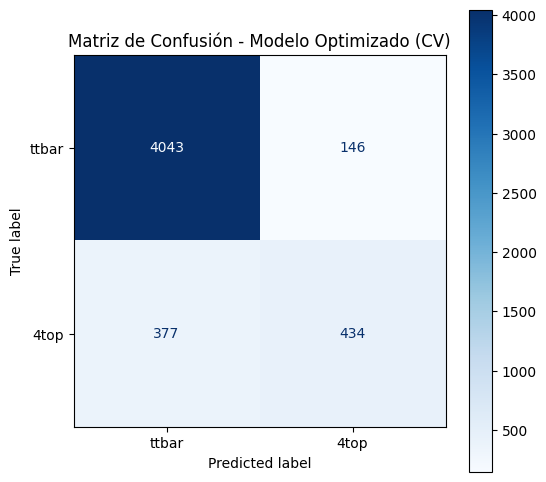

              precision    recall  f1-score   support

       ttbar       0.91      0.97      0.94      4189
        4top       0.75      0.54      0.62       811

    accuracy                           0.90      5000
   macro avg       0.83      0.75      0.78      5000
weighted avg       0.89      0.90      0.89      5000



In [ ]:
# Matriz de confusión para el modelo optimizado
cm_best = confusion_matrix(target, ypred_best)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_best, display_labels=['ttbar', '4top']
)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Matriz de Confusión - Modelo Optimizado (CV)')
plt.show()

# Reporte de métricas actualizado
print(
    classification_report(target, ypred_best, target_names=['ttbar', '4top'])
)

**Construya la matriz de confusión para el modelo optimizado**

Preguntas:

- ¿Cuál es la accuracy del modelo optimizado?
- ¿Cuál es la precision para la clase 4top?
- ¿Cuál es el recall para la clase 4top?
- ¿Cuál es el F1-score para la clase 4top?
- ¿Qué métrica mejoró más respecto al benchmark lineal?
- ¿Qué métrica empeoró o cambió muy poco?
- ¿La mejora en accuracy refleja una mejora real para la clase 4top?
- ¿El modelo optimizado detecta mejor la clase minoritaria que el benchmark lineal?

Complete la tabla de comparación


| Modelo            | Accuracy | Precision `4top` | Recall `4top` | F1-score `4top` | Comentario |
| ----------------- | -------: | ---------------: | ------------: | --------------: | ---------- |
| Benchmark lineal  |   0.90   |       0.75       |       0.55    |       0.63      |  Desempeño limitado por la frontera lineal          |
| Modelo optimizado |   0.90   |       0.75       |       0.54    |       0.62      |  Sin mejora, mantiene alto sesgo e incapacidad de separar clases          |

- ¿El modelo optimizado mejora todas las métricas o solo algunas?
- Si una métrica mejora pero otra empeora, ¿cómo decidiría cuál modelo es mejor?
- ¿La mejora justifica usar un modelo más complejo?


**RESPUESTAS:**

1. 0.90.

2. 0.75

3. 0.54

4. 0.62

5. Ninguna. El desempeño no mostró mejoría relevante en ninguna métrica.

6. La Accuracy y Precision permanecieron iguales ($0.90$ y $0.75$), mientras que el Recall ($0.55 \to 0.54$) y el F1-score ($0.63 \to 0.62$) empeoraron ambas por un decimal.

7. No. La accuracy no cambió ($0.90$ en ambos casos) y sigue la tendencia de que se pierde casi la mitad de los eventos de 4top.

8. No. De hecho, detectó 10 eventos menos ($434$ frente a $444$ del benchmark). 

9. No mejora ninguna; el ajuste de hiperparámetros dentro de un espacio lineal no produjo cambios significativos.

10. Priorizando el F1-score (o el Recall) de la clase de interés (4top), ya que mide la capacidad real de capturar la señal sin inflar el resultado por el desbalance de clases.

11. No, porque no existió una mejora real en el rendimiento discriminativo.

#### Diagnóstico final

- ¿Qué modelo elegiría para reportar y por qué?
- ¿Qué limitación importante todavía tiene el modelo?

**RESPUESTAS:**

1. El Benchmark lineal original (o más simple), ya que la optimización no aportó ningún beneficio práctico en la detección de 4top.

2. La rigidez de la frontera lineal (alto bias reflejado en underfitting). El modelo no tiene la capacidad matemática de capturar las relaciones no lineales entre las variables del cuadrimomento sin un kernel que no sea lineal o una manera distinta de tomar y analizar los datos.

## Actividad final: mejorar el modelo

Hasta ahora usamos un conjunto limitado de features para construir y optimizar nuestros modelos. Sin embargo, el desempeño de un modelo no depende solo del algoritmo o de los hiperparámetros: también depende de la información que le entregamos.

En este dataset, cada evento contiene información de varias partículas reconstruidas. Como los eventos `4top` suelen ser más complejos que los eventos `ttbar`, es razonable pensar que usar más información del evento podría ayudar al modelo a distinguir mejor ambas clases.

**Proponga una estrategia para mejorar el modelo explorando nuevas features o usando una representación más completa de los eventos.**

Puede considerar, por ejemplo:

- incluir información de más partículas;
- usar todas las partículas disponibles;
- construir variables derivadas;
- modificar el tratamiento de valores faltantes;
- comparar distintos subconjuntos de features;
- cambiar la métrica usada para optimizar el modelo.

Luego evalúe si su propuesta mejora el desempeño respecto al modelo anterior.

### Preguntas

1. ¿Qué cambio hizo?
4. ¿Mejoró la detección de eventos `4top`?
5. ¿Qué ocurrió con la matriz de confusión?
6. ¿La mejora justifica el aumento de complejidad?
7. ¿Qué aprendió sobre la importancia de las features en este problema?

Mejores parámetros: {'svc__C': 1, 'svc__gamma': 'scale'}


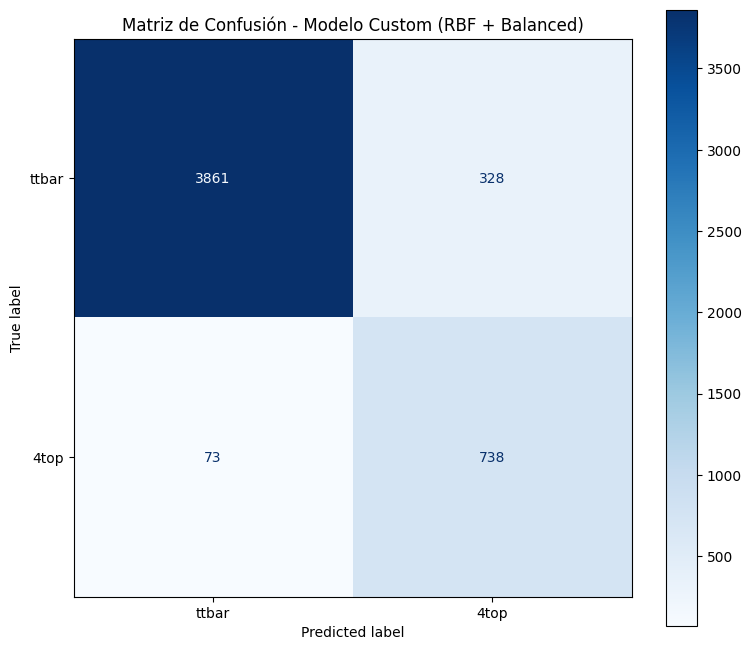

              precision    recall  f1-score   support

       ttbar       0.98      0.92      0.95      4189
        4top       0.69      0.91      0.79       811

    accuracy                           0.92      5000
   macro avg       0.84      0.92      0.87      5000
weighted avg       0.93      0.92      0.92      5000



In [ ]:
# Usar todas las características disponibles
X_custom = features.select_dtypes(include=[np.number]).copy()
X_custom = X_custom.fillna(0)

# Crear Pipeline No Lineal con Pesos Balanceados
pipeline_rbf = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf', class_weight='balanced', random_state=42)
)

# PASO 3: Optimización enfocada en F1-score
param_grid = {
    'svc__C': [1, 10, 100],
    'svc__gamma': ['scale', 'auto', 0.01, 0.1]
}

grid_custom = GridSearchCV(
    pipeline_rbf,
    param_grid,
    cv=cv,
    scoring='f1',  # Optimizamos directamente el F1 de la clase 4top
    n_jobs=-1
)

grid_custom.fit(X_custom, target)
best_custom_model = grid_custom.best_estimator_

print("Mejores parámetros:", grid_custom.best_params_)

# Evaluación en Validación Cruzada
ypred_custom = cross_val_predict(best_custom_model, X_custom, target, cv=cv)

# Matriz de Confusión
cm_custom = confusion_matrix(target, ypred_custom)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_custom, display_labels=['ttbar', '4top'])

fig, ax = plt.subplots(figsize=(9, 8))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Matriz de Confusión - Modelo Custom (RBF + Balanced)')
plt.show()

# Reporte de Métricas
print(classification_report(target, ypred_custom, target_names=['ttbar', '4top']))

**RESPUESTAS:**

1. Se incluyeron todas las variables disponibles del dataset (más información de partículas), se cambió la frontera de decisión a un kernel no lineal (RBF) con balanceo de clases , y se optimizaron los hiperparámetros enfocados en maximizar el $F_1$-score.

2. Sí, drásticamente. El Recall de 4top saltó del $54\%$ al $91\%$ (capturando 738 de los 811 eventos reales), y el $F_1$-score subió de $0.62$ a $0.79$, una gran diferencia.

3. Los Falsos Negativos colapsaron de $377$ a solo $73$ (eventos de $4$ top que antes se perdían). Aunque aumentaron levemente los Falsos Positivos ($328$), la matriz ahora muestra una diagonal principal fuerte y un desempeño balanceado en ambas clases. Ambas predicciones (4 top y ttbar) erran un $\sim10$% de lo que predicen, son alredeor de 800 los datos de 4 top, de los que el modelo logra predecir bien 738 y mal 73, un porcentaje de error similar con ttbar.

4. Totalmente. Pasamos de un modelo que ignoraba prácticamente la mitad de la señal física a uno que detecta el $91\%$ de los eventos raros de $4$ top, incrementando significativamente la capacidad predictiva real.  

5. Que limitar las features descarta correlaciones cinemáticas clave de los cuadrimomentos (se pierde información relevante). La física de procesos complejos como $4$ top requiere toda la información del evento combinada con relaciones no lineales para poder separarse del fondo de ttbar.